Imports

In [18]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.applications.resnet50 import preprocess_input 
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau



In [19]:
data_path = '/kaggle/input/utkface-new/UTKFace/'

image_filenames = os.listdir(data_path)
labels = [int(filename.split('_')[0]) for filename in image_filenames] 

df = pd.DataFrame({
    'filename': image_filenames,
    'age': labels
})

csv_path = '/kaggle/working/utkface_labels.csv'
df.to_csv(csv_path, index=False)




Extract age from File name

In [20]:
csv_path = '/kaggle/working/utkface_labels.csv'
df = pd.read_csv(csv_path)

df['age_bin'] = pd.cut(df['age'], bins=10, labels=False)

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['age_bin'], random_state=42)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

data_path = '/kaggle/input/utkface-new/UTKFace/'

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=data_path,
    x_col='filename',
    y_col='age',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=data_path,
    x_col='filename',
    y_col='age',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)

Found 18966 validated image filenames.
Found 4742 validated image filenames.


In [21]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.summary()


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

Freeze model and build custom layers

In [22]:
for layer in base_model.layers:
    layer.trainable = False

Custom layer and Model

In [23]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(1, activation='linear', name='age_output')(x) 
model = Model(inputs=base_model.input, outputs=x)


Train custom Layer

In [24]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)


history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=train_gen.samples // train_gen.batch_size,
    validation_steps=val_gen.samples // val_gen.batch_size,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 279s 452ms/step - loss: 453.3906 - mae: 15.5314 - val_loss: 122.2571 - val_mae: 8.2576 - learning_rate: 0.0010
Epoch 2/10
  1/592 ━━━━━━━━━━━━━━━━━━━━ 47s 80ms/step - loss: 84.7439 - mae: 6.9675

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 84.7439 - mae: 6.9675 - val_loss: 122.2268 - val_mae: 8.2717 - learning_rate: 0.0010
Epoch 3/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 266s 449ms/step - loss: 141.3941 - mae: 8.8550 - val_loss: 107.3358 - val_mae: 7.5350 - learning_rate: 0.0010
Epoch 4/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 137.6535 - mae: 9.1692 - val_loss: 107.1113 - val_mae: 7.5210 - learning_rate: 0.0010
Epoch 5/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 265s 448ms/step - loss: 134.8521 - mae: 8.5852 - val_loss: 105.6126 - val_mae: 7.4607 - learning_rate: 0.0010
Epoch 6/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 218.9035 - mae: 9.3133 - val_loss: 105.5803 - val_mae: 7.4547 - learning_rate: 0.0010
Epoch 7/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 272s 459ms/step - loss: 128.3954 - mae: 8.3683 - val_loss: 103.7472 - val_mae: 7.4639 - learning_rate: 0.0010
Epoch 8/10
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 128.3057 - mae: 9.2551 - val_loss: 104.8851 - val_mae: 7

Fine Tune

In [25]:
print("Total layers in base model:", len(base_model.layers))

for layer in base_model.layers[-10:]:
    layer.trainable = True   

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='mean_squared_error',
    metrics=['mae']
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,  
    steps_per_epoch=train_gen.samples // train_gen.batch_size,
    validation_steps=val_gen.samples // val_gen.batch_size,
    callbacks=[early_stop],
    verbose=1
)



Total layers in base model: 175
Epoch 1/5
592/592 ━━━━━━━━━━━━━━━━━━━━ 294s 475ms/step - loss: 119.2197 - mae: 8.1401 - val_loss: 95.5592 - val_mae: 6.9843
Epoch 2/5
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 120.2970 - mae: 9.7288 - val_loss: 95.5378 - val_mae: 6.9836
Epoch 3/5
592/592 ━━━━━━━━━━━━━━━━━━━━ 269s 454ms/step - loss: 113.6056 - mae: 7.8728 - val_loss: 92.7630 - val_mae: 6.8499
Epoch 4/5
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 58.6310 - mae: 6.0054 - val_loss: 92.7410 - val_mae: 6.8505
Epoch 5/5
592/592 ━━━━━━━━━━━━━━━━━━━━ 264s 447ms/step - loss: 110.4009 - mae: 7.8407 - val_loss: 90.5124 - val_mae: 6.7821


Visualize

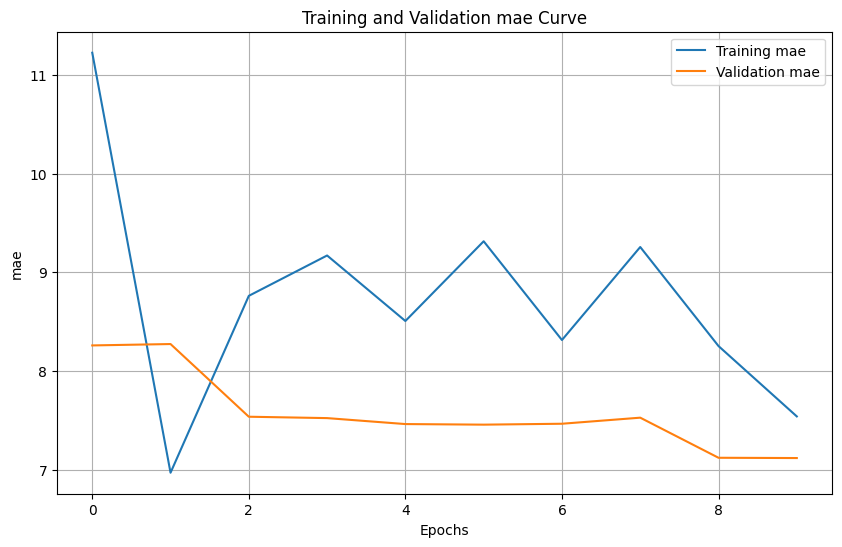

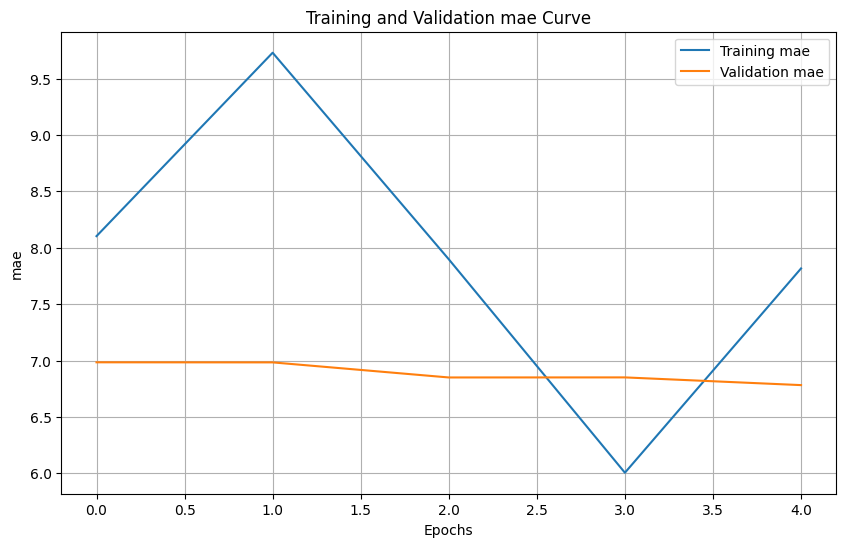

In [28]:
import matplotlib.pyplot as plt

def plot_loss(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['mae'], label='Training mae')
    plt.plot(history.history['val_mae'], label='Validation mae')
    plt.title('Training and Validation mae Curve')
    plt.xlabel('Epochs')
    plt.ylabel('mae')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(history_head)
plot_loss(history_finetune)

input image for test

In [37]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

img_path = "/kaggle/input/photo-for/images (2).jpg"   

img = load_img(img_path, target_size=(224, 224))

img = img_to_array(img)

img = np.expand_dims(img, axis=0)

img = preprocess_input(img)

predicted_age = model.predict(img)[0][0]

print("Predicted Age:", predicted_age)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Age: 50.479679107666016
